PROJECT: Social Media & Network Analytics Dashboard

AIM: To know what platforms is mostly used and what is currently trending by its users

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


LIBRARIES AND THEIR APPLICATIONS FUNCTIONS:

Pandas: To handles Data Representation.

Numpy: It supports the underlying math for your Foundational Metrics.

Seaborn: It addresses Visualization and Perception Design

Matplotlib: It provides the "Canvas" for your Initial Visual Outputs


In [3]:
df = pd.read_csv('social_media_engagement1.csv')
print(df)


    post_id   platform post_type         post_time  likes  comments  shares  \
0         1   Facebook     image   8/17/2023 14:45   2121       474     628   
1         2   Facebook  carousel    5/14/2023 0:45   3660       432     694   
2         3  Instagram      poll   2/21/2023 16:15   4955       408     688   
3         4    Twitter     image   11/16/2023 0:45   1183        90     187   
4         5    Twitter     video    5/23/2023 0:30   3499       247     286   
..      ...        ...       ...               ...    ...       ...     ...   
95       96  Instagram  carousel   7/12/2023 17:45     36       294     911   
96       97    Twitter     video  10/27/2023 23:45    314       108     458   
97       98    Twitter      text     8/5/2023 8:45    229       179      38   
98       99  Instagram      poll  12/29/2023 12:15   5000       500     204   
99      100  Instagram     image    6/6/2023 21:00   4483       357      25   

     post_day sentiment_score  
0    Thursday      

The dataset was obtained from kaggle and uploaded as a csv document.

In [4]:
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB
None
          post_id        likes   comments      shares
count  100.000000   100.000000  100.00000  100.000000
mean    50.500000  2381.810000  202.66000  415.650000
std     29.011492  1632.573284  138.84067  283.877601
min      1.000000    15.000000   10.00000   16.000000
25%     25.750000   895.750000   89.75000  183.000000
50%     50.500000  2220

DATA SCHEMA: The df.info() output provides the variable definitions, file size and data types.

DESCRIPTIVE ANALYSIS: The df.describe() function calculate the mean, variance, and distribution as required by the task.


In [5]:
#MEAN AND VARIANCE (NUMERICAL COLUMNS)
print("MEAN VALUES")
print(df.mean(numeric_only=True))

print("VARIANCE VALUES")
print(df.var(numeric_only=True))

#CHECK MISSING VALUES
print("MISSING VALUES")
print(df.isnull().sum())

#CHECK DUPLICATES
print("DUPLICATE RECORDS")
print(df.duplicated().sum())

MEAN VALUES
post_id       50.50
likes       2381.81
comments     202.66
shares       415.65
dtype: float64
VARIANCE VALUES
post_id     8.416667e+02
likes       2.665296e+06
comments    1.927673e+04
shares      8.058649e+04
dtype: float64
MISSING VALUES
post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64
DUPLICATE RECORDS
0


The above codes are used to compute the mean and variance for various information in the data
(numeric_only=True) helps by computing the mean for numeric values only.

In [6]:
usage_summary = df.groupby(['platform', 'post_type']).size().reset_index(name='count')

most_used = usage_summary.sort_values(['platform', 'count'], ascending=[True, False]).drop_duplicates('platform')
print("Most Used Post Type Per Platform")
print(most_used)

Most Used Post Type Per Platform
     platform post_type  count
0    Facebook  carousel     10
5   Instagram  carousel      9
13    Twitter      text      8


df.groupby(['platform', 'post_type']): Python looks at your dataset and creates "buckets." It creates a bucket for every unique combination it finds.

.size(): Inside each of those buckets, Python simply counts how many rows exist. This tells you the total number of posts for that specific category.

.reset_index(name='count'): By default, groupby creates a complex structure. This function flattens the data back into a standard table and names the new column "count."

.sort_values(['platform', 'count'], ascending=[True, False]):
This performs a multi-level sort:

platform (True): Sorts platforms alphabetically .

count (False): Within each platform, it sorts the counts from highest to lowest.

.drop_duplicates('platform'):
This is the "filtering" step. It goes through the list and keeps only the first occurrence of each platform it sees. Because we just sorted the counts from highest to lowest, the "first occurrence" is guaranteed to be the "most used" post type.

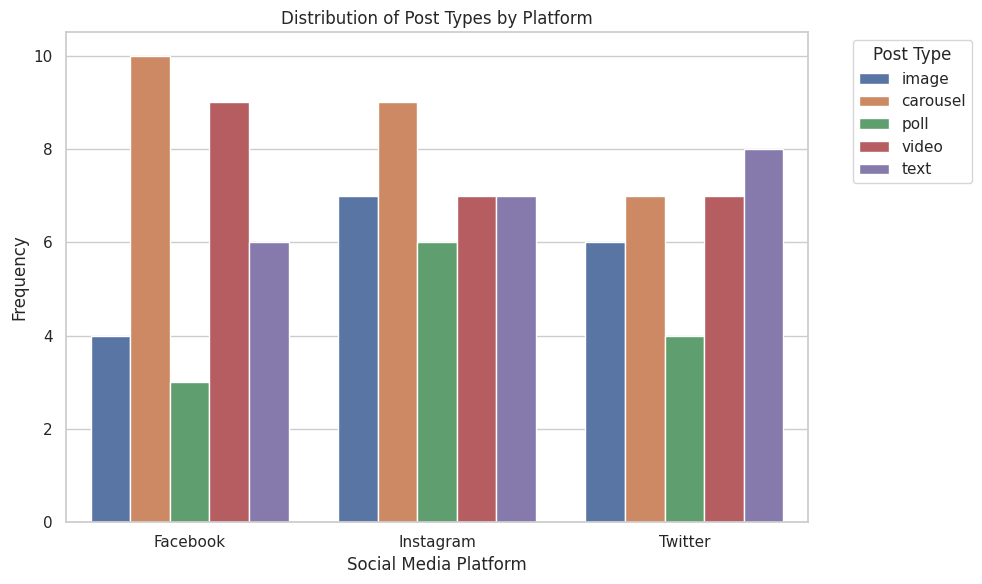

In [7]:
sns.set_theme(style="whitegrid")

# To show the distribution of usage of every post type in their platforms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='platform', hue='post_type')
plt.title('Distribution of Post Types by Platform')
plt.xlabel('Social Media Platform')
plt.ylabel('Frequency')
plt.legend(title='Post Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('post_type_distribution.png')
plt.show()

The above codes creates a grouped bar chart (count plot) to display the platfroms and what is currently trending by the users.

sns.countplot: Unlike a standard bar chart where you have to provide the numbers, a count plot is smart. It looks at your raw data, counts the rows automatically, and draws the bars.

data=df: Tells Seaborn to look inside your DataFrame.

x='platform': Sets the primary categories on the horizontal axis (Facebook, Instagram, Twitter).

hue='post_type': This is the most important part for Milestone 1. It "slices" the data a second time. Instead of one bar for Facebook, you get a group of bars—one for each type of post (Video, Image, etc.).

bbox_to_anchor: By setting it to (1.05, 1), you are moving the legend outside the chart area to the right.

tight_layout(): This automatically adjusts the margins. It ensures that your title and axis labels don't get cut off when you save the file.

savefig(): This creates a physical file on your computer.